# 03 — Loss, Gradients, and Backpropagation (Manual NumPy)

Loss quantifies the mistake; gradients quantify parameter responsibility. Backpropagation is repeated chain rule, not a separate mysterious learning mechanism.


For softmax + cross entropy, the output sensitivity simplifies to
$$\frac{\partial \mathcal L}{\partial z^{(2)}}=\frac{1}{B}(\hat Y-Y).$$
Earlier gradients are obtained by multiplying this sensitivity backward through weights and activation derivatives.


train (5000, 784) test (1000, 784)


loss 2.3040998706978977
dW2 (16, 10) norm 0.4645774622956882
dW1 (784, 16) norm 0.5939363825603126
loss before 2.3040998706978977 after one step 1.9998086621787174


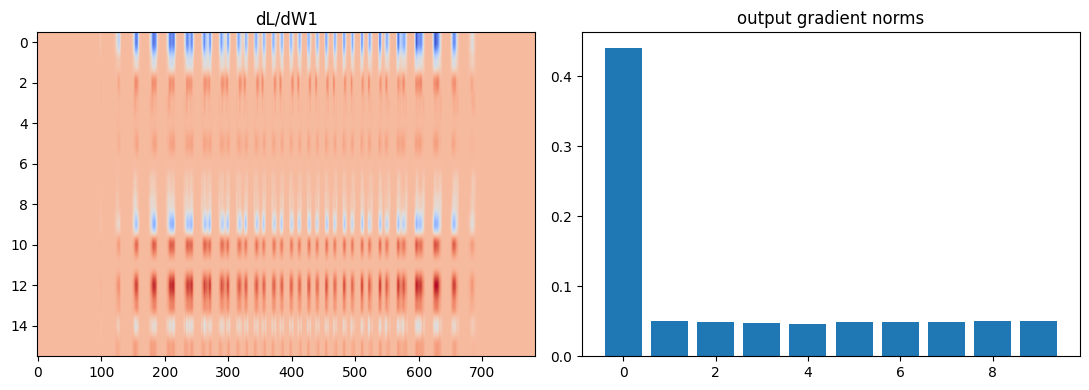

In [1]:
from pathlib import Path
import urllib.request, numpy as np
MNIST_URL='https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
CACHE=Path('data/cache/mnist.npz'); CACHE.parent.mkdir(parents=True,exist_ok=True)
if not CACHE.exists():
    print('Downloading official MNIST archive...')
    urllib.request.urlretrieve(MNIST_URL,CACHE)
with np.load(CACHE) as d:
    x_train_full,y_train_full=d['x_train'],d['y_train']
    x_test_full,y_test_full=d['x_test'],d['y_test']
def balanced(x,y,n):
    ids=np.concatenate([np.flatnonzero(y==c)[:n] for c in range(10)])
    return x[ids],y[ids]
x_train_img,y_train=balanced(x_train_full,y_train_full,500)
x_test_img,y_test=balanced(x_test_full,y_test_full,100)
x_train=x_train_img.reshape(len(x_train_img),-1).astype('float32')/255.0
x_test=x_test_img.reshape(len(x_test_img),-1).astype('float32')/255.0
print('train',x_train.shape,'test',x_test.shape)

import matplotlib.pyplot as plt
rng=np.random.default_rng(42);X=x_train[:32];Y=y_train[:32]
W1=rng.normal(0,.03,(784,16));b1=np.zeros((1,16));W2=rng.normal(0,.05,(16,10));b2=np.zeros((1,10))
z1=X@W1+b1;a1=np.maximum(z1,0);z2=a1@W2+b2;e=np.exp(z2-z2.max(1,keepdims=True));p=e/e.sum(1,keepdims=True);loss=-np.log(p[np.arange(len(Y)),Y]+1e-12).mean();Y1=np.eye(10)[Y]
dz2=(p-Y1)/len(Y);dW2=a1.T@dz2;db2=dz2.sum(0,keepdims=True);dz1=(dz2@W2.T)*(z1>0);dW1=X.T@dz1;db1=dz1.sum(0,keepdims=True)
print('loss',loss);print('dW2',dW2.shape,'norm',np.linalg.norm(dW2));print('dW1',dW1.shape,'norm',np.linalg.norm(dW1))
def L(A,c,B,d):
 z=X@A+c;h=np.maximum(z,0);q=h@B+d;ee=np.exp(q-q.max(1,keepdims=True));pp=ee/ee.sum(1,keepdims=True);return -np.log(pp[np.arange(len(Y)),Y]+1e-12).mean()
print('loss before',L(W1,b1,W2,b2),'after one step',L(W1-.2*dW1,b1-.2*db1,W2-.2*dW2,b2-.2*db2))
fig,axes=plt.subplots(1,2,figsize=(11,4));axes[0].imshow(dW1.T,aspect='auto',cmap='coolwarm');axes[0].set_title('dL/dW1');axes[1].bar(range(10),np.linalg.norm(dW2,axis=0));axes[1].set_title('output gradient norms');plt.tight_layout();plt.show()


**Cause/effect:** update parameters against the gradient → next forward pass changes → hidden representation changes → class probabilities change → loss changes.

**Production connection:** gradient scale affects convergence speed, instability, training cost, and reproducibility.
